In [45]:
import numpy as np
import matplotlib.pyplot as plt
import keras

### Load Dataset

In [46]:
(train_data, train_targets), (test_data, test_targets) = keras.datasets.california_housing.load_data(version="small")
train_data.shape, train_targets.shape, test_data.shape, test_targets.shape

((480, 8), (480,), (120, 8), (120,))

In [47]:
train_data

array([[-1.2224e+02,  3.7730e+01,  2.1000e+01, ...,  2.9300e+03,
         1.2350e+03,  4.5213e+00],
       [-1.2228e+02,  3.7850e+01,  4.8000e+01, ...,  1.0540e+03,
         4.6600e+02,  2.2625e+00],
       [-1.2229e+02,  3.7820e+01,  2.0000e+00, ...,  9.4000e+01,
         5.7000e+01,  2.5625e+00],
       ...,
       [-1.2218e+02,  3.7810e+01,  3.7000e+01, ...,  6.2000e+02,
         2.6600e+02,  5.4446e+00],
       [-1.2219e+02,  3.7790e+01,  2.8000e+01, ...,  1.7370e+03,
         6.6900e+02,  2.9297e+00],
       [-1.2220e+02,  3.7800e+01,  5.2000e+01, ...,  7.0600e+02,
         2.6800e+02,  4.7721e+00]], shape=(480, 8), dtype=float32)

In [48]:
train_targets

array([228400., 132900.,  60000.,  95200., 107000., 122500., 132000.,
       290100., 257800., 390100., 220800., 284900.,  97500., 415300.,
        84200., 185600., 216700., 233100., 127000., 182300.,  92300.,
        90700., 102100., 112500., 350700., 156500., 220700., 147400.,
       216700., 275000., 198200., 119100., 289500., 152500., 125000.,
       104500.,  93800.,  89300., 452600., 128600., 311500.,  90000.,
       218200., 131300.,  67500., 139400., 500001., 182600., 111300.,
       112500., 134700.,  71300., 207400., 331400., 107900.,  87500.,
       342200.,  87100., 314700., 368600., 211600., 338900., 366100.,
       164300.,  91700., 261400., 218500., 155400., 273700.,  81800.,
       138800.,  99700., 156300., 140600., 152700., 108900., 351200.,
       126000., 137500., 196900., 240000., 172800., 254200.,  97500.,
       182700., 162500.,  86100., 226700., 412500., 165900., 327100.,
       162500., 188800., 183800.,  90600., 372000., 275000., 151800.,
       125000., 1291

### Data Preprocessing

In [49]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
x_train = (train_data - mean) / std
x_test = (test_data - mean) / std

In [50]:
x_train

array([[-0.1761497 , -1.5940031 , -2.4240775 , ...,  2.9189088 ,
         2.8009396 ,  0.5019599 ],
       [-0.9574973 ,  0.8883017 ,  0.36945325, ...,  0.08949073,
         0.22832383, -0.6378871 ],
       [-1.1528715 ,  0.26774517, -4.3898954 , ..., -1.358399  ,
        -1.1399465 , -0.4864996 ],
       ...,
       [ 0.9957972 ,  0.06091933, -0.7686519 , ..., -0.5650761 ,
        -0.440757  ,  0.9678804 ],
       [ 0.800423  , -0.35281128, -1.6998289 , ...,  1.119604  ,
         0.9074409 , -0.3012013 ],
       [ 0.6051979 , -0.14598544,  0.7833097 , ..., -0.4353693 ,
        -0.4340662 ,  0.62852   ]], shape=(480, 8), dtype=float32)

In [51]:
train_targets.min(), train_targets.max()

(np.float32(60000.0), np.float32(500001.0))

In [52]:
target_scale_factor = 100000
y_train = train_targets / target_scale_factor
y_test = test_targets / target_scale_factor
y_train

array([2.284  , 1.329  , 0.6    , 0.952  , 1.07   , 1.225  , 1.32   ,
       2.901  , 2.578  , 3.901  , 2.208  , 2.849  , 0.975  , 4.153  ,
       0.842  , 1.856  , 2.167  , 2.331  , 1.27   , 1.823  , 0.923  ,
       0.907  , 1.021  , 1.125  , 3.507  , 1.565  , 2.207  , 1.474  ,
       2.167  , 2.75   , 1.982  , 1.191  , 2.895  , 1.525  , 1.25   ,
       1.045  , 0.938  , 0.893  , 4.526  , 1.286  , 3.115  , 0.9    ,
       2.182  , 1.313  , 0.675  , 1.394  , 5.00001, 1.826  , 1.113  ,
       1.125  , 1.347  , 0.713  , 2.074  , 3.314  , 1.079  , 0.875  ,
       3.422  , 0.871  , 3.147  , 3.686  , 2.116  , 3.389  , 3.661  ,
       1.643  , 0.917  , 2.614  , 2.185  , 1.554  , 2.737  , 0.818  ,
       1.388  , 0.997  , 1.563  , 1.406  , 1.527  , 1.089  , 3.512  ,
       1.26   , 1.375  , 1.969  , 2.4    , 1.728  , 2.542  , 0.975  ,
       1.827  , 1.625  , 0.861  , 2.267  , 4.125  , 1.659  , 3.271  ,
       1.625  , 1.888  , 1.838  , 0.906  , 3.72   , 2.75   , 1.518  ,
       1.25   , 1.29

In [53]:
y_train.min(), y_train.max()

(np.float32(0.6), np.float32(5.00001))

### Modeling

In [54]:
model = keras.Sequential([
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1)
])
model.compiled

False

In [55]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)
model.compiled

True

In [56]:
def get_model():
    model = keras.Sequential([
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1)
    ])

    model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
    )

    return model


### K Fold Validation

In [57]:
k = 4
num_val_samples = len(x_train) // k
num_val_samples

120

In [58]:
# K-Fold Validation
def k_fold(num_epochs=50, k=4):
    all_scores = []
    all_mae_histories = []
    for i in range(k):
        print(f"Processing fold #{i + 1}")
        fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
        fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
        fold_x_train = np.concatenate(
            [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
            axis=0,
        )
        fold_y_train = np.concatenate(
            [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
            axis=0,
        )
        model = get_model()
        history = model.fit(fold_x_train, fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
        )
        scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)
        val_loss, val_mae = scores
        all_scores.append(val_mae)
        mae_history = history.history["val_mean_absolute_error"]
        all_mae_histories.append(mae_history)
    return all_scores, all_mae_histories



In [59]:
all_scores, history = k_fold(50, 4)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [60]:
[round(value, 4) for value in all_scores]

[0.4, 0.408, 0.3922, 0.4556]

In [61]:
round(np.mean(all_scores), 4)

np.float64(0.4139)

In [62]:
average_mae_history = [
    np.mean([x[i] for x in history]) for i in range(num_epochs)
]
average_mae_history


[np.float64(0.9728834331035614),
 np.float64(0.7047955244779587),
 np.float64(0.5895418375730515),
 np.float64(0.5222875028848648),
 np.float64(0.5007252916693687),
 np.float64(0.47648102790117264),
 np.float64(0.456393837928772),
 np.float64(0.4407494440674782),
 np.float64(0.43941348046064377),
 np.float64(0.41394250839948654)]

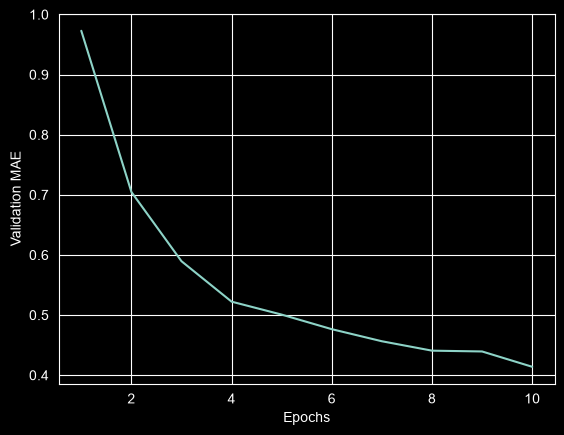

In [63]:
epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [64]:
all_scores, history = k_fold(200, 4)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [65]:
[round(value, 4) for value in all_scores]

[0.4286, 0.417, 0.3784, 0.4218]

In [66]:
round(np.mean(all_scores), 4)

np.float64(0.4114)

In [67]:
average_mae_history = [
    np.mean([x[i] for x in history]) for i in range(num_epochs)
]
average_mae_history


[np.float64(0.8658877164125443),
 np.float64(0.6699139773845673),
 np.float64(0.5683791637420654),
 np.float64(0.5198573023080826),
 np.float64(0.49062877893447876),
 np.float64(0.46400777250528336),
 np.float64(0.4528163820505142),
 np.float64(0.4344785585999489),
 np.float64(0.4210475906729698),
 np.float64(0.41143133491277695)]

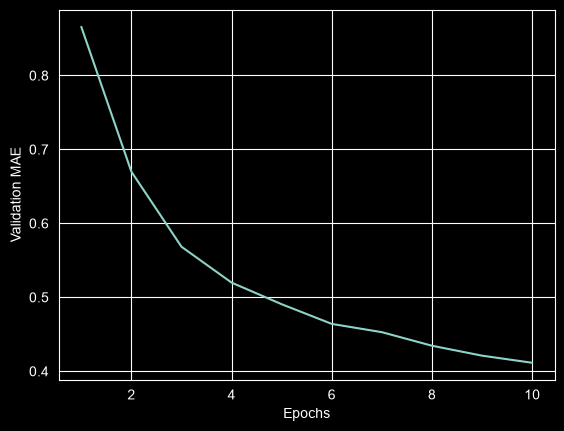

In [68]:
epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

### Final Model - Fine Tuned


In [69]:
model = get_model()
model.fit(x_train, y_train, epochs=130, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    x_test, y_test
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2923 - mean_absolute_error: 0.3106 


In [70]:
round(test_mean_absolute_error, 3), test_mean_squared_error

(0.311, 0.2923237681388855)

### prediction

In [71]:
predictions = model.predict(x_test)
predictions[0], y_test[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


(array([2.472246], dtype=float32), np.float32(2.188))